## 1. 问题背景

我们希望用一条直线去拟合数据点：

$$
\hat y = wx + b
$$

其中：

- $x$：输入
- $\hat y$：模型预测值
- $w$：斜率（weight）
- $b$：截距（bias）

我们假设真实数据来自下面这个模型：

$$
y = 2x + 1 + \text{noise}
$$

也就是说，真实斜率接近 2，真实截距接近 1，但由于加入了噪声，所以数据点不会完全落在同一条直线上。

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

## 2. 生成简单线性数据

In [3]:
# =========================================================
# 1. Generate simple linear data
#    True model: y = 2x + 1 + noise
# =========================================================
np.random.seed(42)

x = np.linspace(0, 5, 30)
noise = np.random.normal(0, 0.8, size=x.shape)
y = 2.0 * x + 1.0 + noise

n = len(x)

print("样本数 n =", n)
print("前5个 x =", x[:5])
print("前5个 y =", y[:5])

样本数 n = 30
前5个 x = [0.         0.17241379 0.34482759 0.51724138 0.68965517]
前5个 y = [1.39737132 1.23421615 2.207806   3.25290664 2.19198765]


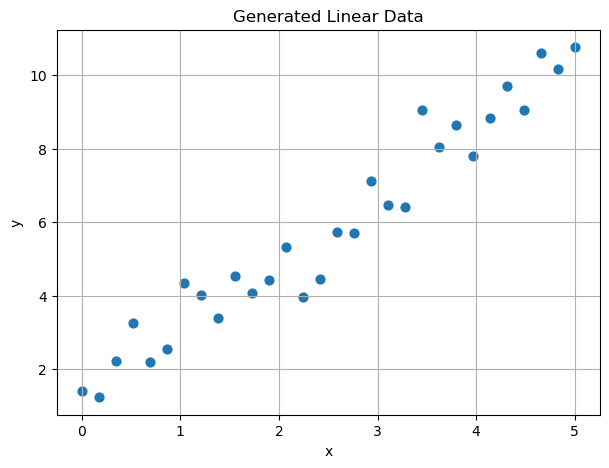

In [4]:
plt.figure(figsize=(7, 5))
plt.scatter(x, y, s=40)
plt.title("Generated Linear Data")
plt.xlabel("x")
plt.ylabel("y")
plt.grid(True)
plt.show()

### 数据含义

这里我们生成了 30 个样本点。  
如果没有噪声，那么所有点都应该严格落在直线

$$
y = 2x + 1
$$

上。  
但现实数据常常有误差，因此我们加入了高斯噪声：

$$
\text{noise} \sim \mathcal N(0, 0.8^2)
$$

这让问题更接近真实机器学习任务。

## 3. 定义模型和损失函数

线性回归模型：

$$
\hat y_i = wx_i + b
$$

对所有样本，我们用均方误差（Mean Squared Error, MSE）来衡量预测和真实值之间的差异：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(\hat y_i - y_i)^2
$$

把 $\hat y_i = wx_i + b$ 代入后：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(wx_i + b - y_i)^2
$$

目标就是找到一组最优参数 $(w,b)$，使得损失函数 $J(w,b)$ 尽可能小。

In [5]:
# =========================================================
# 2. Define model and cost function
# =========================================================
def predict(x, w, b):
    """Linear model: y_hat = w*x + b"""
    return w * x + b


def mse_cost(x, y, w, b):
    """Mean Squared Error cost"""
    y_hat = predict(x, w, b)
    return np.mean((y_hat - y) ** 2)

## 4. 梯度公式推导

我们现在推导损失函数对参数 $w$ 和 $b$ 的偏导数。

损失函数为：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(wx_i + b - y_i)^2
$$

令误差项为：

$$
e_i = wx_i + b - y_i
$$

那么损失函数可以写成：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}e_i^2
$$

---

### 对 $w$ 求偏导

根据链式法则：

$$
\frac{\partial J}{\partial w}
=
\frac{1}{n}\sum_{i=1}^{n} 2 e_i \frac{\partial e_i}{\partial w}
$$

而

$$
e_i = wx_i + b - y_i
\quad\Rightarrow\quad
\frac{\partial e_i}{\partial w} = x_i
$$

所以：

$$
\frac{\partial J}{\partial w}
=
\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

---

### 对 $b$ 求偏导

同理：

$$
\frac{\partial J}{\partial b}
=
\frac{1}{n}\sum_{i=1}^{n} 2 e_i \frac{\partial e_i}{\partial b}
$$

而

$$
\frac{\partial e_i}{\partial b} = 1
$$

因此：

$$
\frac{\partial J}{\partial b}
=
\frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

---

### 最终梯度公式

$$
\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

$$
\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

In [6]:
def gradients(x, y, w, b):
    """
    Gradients of MSE with respect to w and b

    J(w,b) = (1/n) * sum((wx+b-y)^2)

    dJ/dw = (2/n) * sum((wx+b-y)*x)
    dJ/db = (2/n) * sum(wx+b-y)
    """
    y_hat = predict(x, w, b)
    error = y_hat - y
    dw = (2 / len(x)) * np.sum(error * x)
    db = (2 / len(x)) * np.sum(error)
    return dw, db

## 5. 梯度下降（Gradient Descent）

有了梯度之后，我们就可以不断更新参数：

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

其中：

- $\alpha$：学习率（learning rate）
- 梯度决定参数应该往哪个方向调整
- 负号表示朝着损失减小的方向前进

我们会记录每一次迭代中的：

- $w$
- $b$
- 损失值 $J(w,b)$

这样就能可视化梯度下降的整个过程。

In [7]:
# =========================================================
# 3. Gradient Descent
# =========================================================
def gradient_descent(x, y, w0, b0, lr=0.05, epochs=60):
    """
    Run gradient descent and record the full history
    """
    w, b = w0, b0

    w_history = [w]
    b_history = [b]
    cost_history = [mse_cost(x, y, w, b)]

    for _ in range(epochs):
        dw, db = gradients(x, y, w, b)
        w = w - lr * dw
        b = b - lr * db

        w_history.append(w)
        b_history.append(b)
        cost_history.append(mse_cost(x, y, w, b))

    return np.array(w_history), np.array(b_history), np.array(cost_history)

## 6. 运行梯度下降

In [8]:
# Initial guess
w0, b0 = -1.0, 4.0

# Run GD
w_hist, b_hist, cost_hist = gradient_descent(x, y, w0, b0, lr=0.05, epochs=60)

print(f"Initial parameters: w = {w_hist[0]:.3f}, b = {b_hist[0]:.3f}, cost = {cost_hist[0]:.3f}")
print(f"Final parameters:   w = {w_hist[-1]:.3f}, b = {b_hist[-1]:.3f}, cost = {cost_hist[-1]:.3f}")

Initial parameters: w = -1.000, b = 4.000, cost = 37.284
Final parameters:   w = 1.605, b = 2.020, cost = 0.595


### 结果解释

- 初始参数 $(w_0, b_0)$ 是随便设定的，不一定接近真实答案  
- 经过多轮更新后，参数会逐渐靠近最优值  
- 损失函数通常会不断减小

如果训练正常，那么最终得到的 $w$ 应该接近 2，$b$ 应该接近 1。

## 7. 构造损失函数曲面 $J(w,b)$

为了更直观地理解梯度下降，我们可以把不同参数组合 $(w,b)$ 对应的损失值都算出来。

也就是说，在很多不同的 $w$ 和 $b$ 上计算：

$$
J(w,b) = \frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2
$$

这样就能得到一个二维参数空间中的“损失曲面”。

In [9]:
# =========================================================
# 4. Build cost surface J(w,b)
# =========================================================
w_vals = np.linspace(-2.0, 4.0, 120)
b_vals = np.linspace(-2.0, 6.0, 120)
W, B = np.meshgrid(w_vals, b_vals)

J = np.zeros_like(W)

for i in range(W.shape[0]):
    for j in range(W.shape[1]):
        J[i, j] = mse_cost(x, y, W[i, j], B[i, j])

## 8. 可视化结果

### 8.1 损失值随迭代轮数下降

这个图用于观察梯度下降是否真的让损失不断减小。  
如果学习率合适，曲线一般会逐渐下降并趋于平稳。

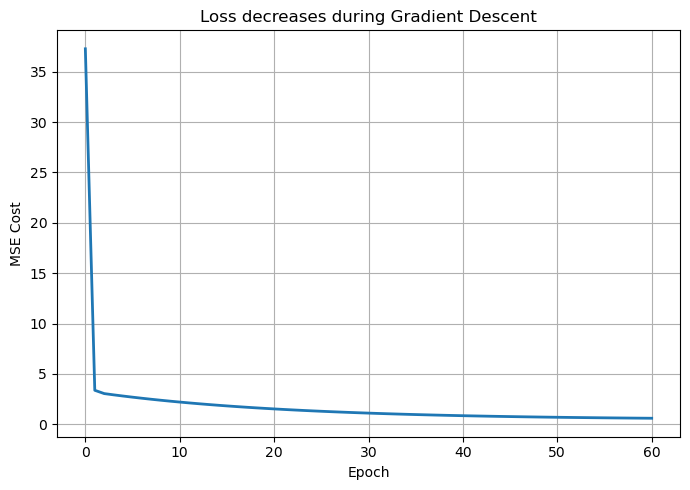

In [10]:
# -------- 5.1 Loss vs epoch --------
fig1, ax1 = plt.subplots(figsize=(7, 5))
ax1.plot(cost_hist, linewidth=2)
ax1.set_title("Loss decreases during Gradient Descent")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("MSE Cost")
ax1.grid(True)
fig1.tight_layout()
plt.show()

### 8.2 数据点与最终拟合直线

这个图展示模型最终学到的直线是否贴近原始数据。

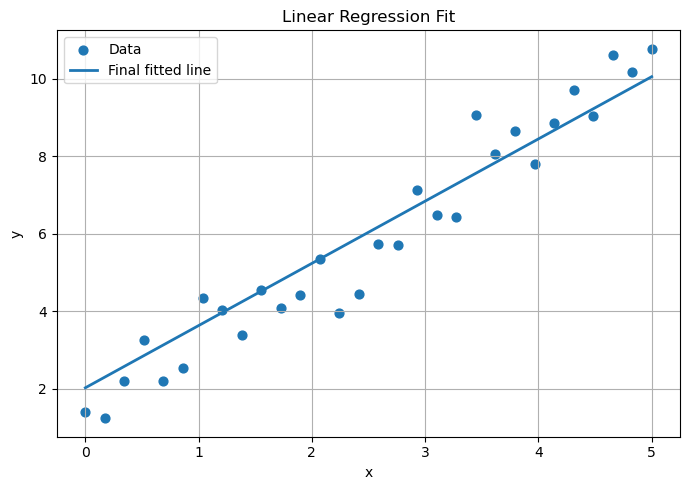

In [11]:
# -------- 5.2 Data and fitted line --------
fig2, ax2 = plt.subplots(figsize=(7, 5))
ax2.scatter(x, y, s=40, label="Data")
ax2.plot(x, predict(x, w_hist[-1], b_hist[-1]), linewidth=2, label="Final fitted line")
ax2.set_title("Linear Regression Fit")
ax2.set_xlabel("x")
ax2.set_ylabel("y")
ax2.legend()
ax2.grid(True)
fig2.tight_layout()
plt.show()

### 8.3 三维损失曲面 + 梯度下降路径

这个图最有教学意义：

- 横轴：参数 $w$
- 纵轴：参数 $b$
- 高度：损失值 $J(w,b)$
- 红线：梯度下降走过的路径

可以把它理解成：  
我们站在一个山面上，目标是沿着坡度往“谷底”走。  
梯度下降每一步都在寻找“下降最快”的方向。

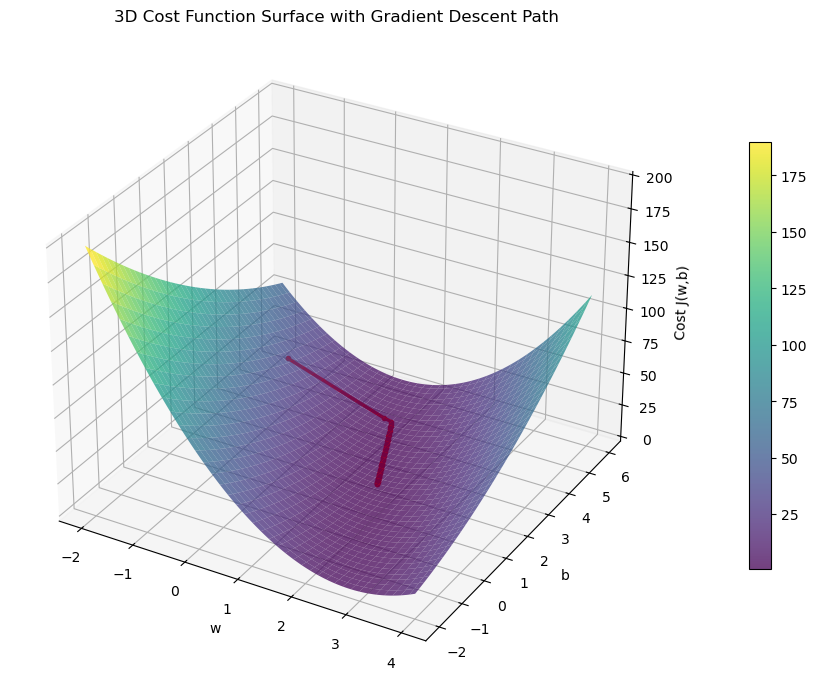

In [12]:
# -------- 5.3 3D cost surface + GD trajectory --------
fig3 = plt.figure(figsize=(9, 7))
ax3 = fig3.add_subplot(111, projection="3d")

surf = ax3.plot_surface(W, B, J, alpha=0.75, cmap="viridis", edgecolor="none")
ax3.plot(w_hist, b_hist, cost_hist, color="red", linewidth=2.5, marker="o", markersize=3)

ax3.set_title("3D Cost Function Surface with Gradient Descent Path")
ax3.set_xlabel("w")
ax3.set_ylabel("b")
ax3.set_zlabel("Cost J(w,b)")
fig3.colorbar(surf, ax=ax3, shrink=0.65, pad=0.1)
fig3.tight_layout()
plt.show()

### 8.4 等高线图 + 梯度下降路径

三维图有时不够直观，所以再看二维等高线图。

等高线图中：

- 每条曲线表示相同的损失值
- 红色轨迹表示参数从初始点一步步走向最优点
- 越靠近中心区域，损失越小

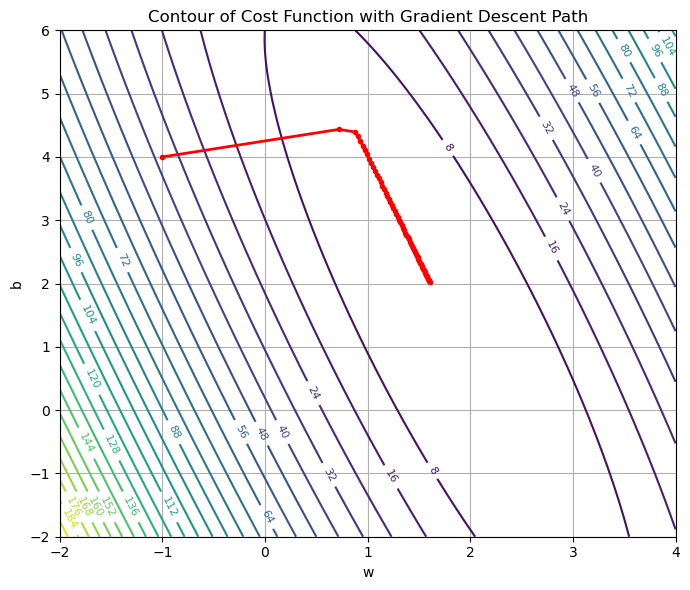

In [13]:
# -------- 5.4 Contour plot + GD trajectory --------
fig4, ax4 = plt.subplots(figsize=(7, 6))
contour = ax4.contour(W, B, J, levels=30, cmap="viridis")
ax4.clabel(contour, inline=True, fontsize=8)
ax4.plot(w_hist, b_hist, color="red", marker="o", markersize=3, linewidth=2)

ax4.set_title("Contour of Cost Function with Gradient Descent Path")
ax4.set_xlabel("w")
ax4.set_ylabel("b")
ax4.grid(True)
fig4.tight_layout()
plt.show()

## 9. 关键知识点总结

### 9.1 模型
线性回归模型：

$$
\hat y = wx + b
$$

### 9.2 损失函数
均方误差：

$$
J(w,b)=\frac{1}{n}\sum_{i=1}^{n}(wx_i+b-y_i)^2
$$

### 9.3 梯度
对参数求偏导：

$$
\frac{\partial J}{\partial w} = \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)x_i
$$

$$
\frac{\partial J}{\partial b} = \frac{2}{n}\sum_{i=1}^{n}(wx_i+b-y_i)
$$

### 9.4 参数更新
梯度下降更新规则：

$$
w \leftarrow w - \alpha \frac{\partial J}{\partial w}
$$

$$
b \leftarrow b - \alpha \frac{\partial J}{\partial b}
$$

---

从图像上看，梯度下降就是让参数点 $(w,b)$ 在损失曲面上不断向更低的位置移动，直到靠近最优解。